# Binary Classification with CNNs: Kaggle Data Set
With transfer learning from the pneumonia MNIST data set

## Setup

In [18]:
import numpy as np
import pandas as pd
import seaborn as sb
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import datetime

notebook_start_time = datetime.datetime.now()

In [2]:
test_dir = "data/test"
train_dir = "data/train"
validation_dir = "data/val"

height, width, channels = 150, 150, 1

batch_size = 32

# While working, I discovered that the tf.keras.preprocessing.image.ImageDataGenerator class is deprecated
# using this new API instead

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode='int',
    color_mode='grayscale',
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode='int',
    color_mode='grayscale',
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode='int',
    color_mode='grayscale',
)

# because the outputs are batched, we have to concatenate all the batches
y_true = np.concatenate([y for x, y in test_ds], axis=0)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.


2025-05-09 22:46:21.985802: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 624 files belonging to 2 classes.


2025-05-09 22:46:22.705260: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [21]:
def confusion_matrix_two_by_two(ax, y_true, y_pred) -> None:
    cm = confusion_matrix(y_true, y_pred)
    sb.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.xaxis.set_ticklabels([f'Normal ({(cm[0][0] + cm[1][0])/len(y_pred):.3f})', f'Pneumonia ({(cm[0][1] + cm[1][1])/len(y_pred):.3f})'])
    ax.yaxis.set_ticklabels([f'Normal ({(cm[0][0] + cm[0][1])/len(y_pred):.3f})', f'Pneumonia ({(cm[1][0] + cm[1][1])/len(y_pred):.3f})'])
    ax.set_title('Confusion Matrix')

def summary_graphics(history, model):
    y_pred = np.round(model.predict(test_ds))
    fig, ax = plt.subplots(1, 3)
    fig.set_size_inches(16, 5)
    ax = ax.flatten()

    # true/false positive/negative rates (better than accuracy for imbalanced data!)
    ax[0].plot(history.history['tp'], label = 'True Positives', color='g')
    #ax[0].plot(history.history['fp'], label = 'False Positives')
    ax[0].plot(history.history['tn'], label = 'True Negatives', color='r')
    #ax[0].plot(history.history['fn'], label = 'False Negatives', color='orange')
    ax[0].grid(True)
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Metric Value')
    ax[0].legend(loc='right')
    ax[0].set_title('True Positive and True Negative Rates')

    # loss
    ax[1].plot(history.history['loss'], label='Loss')
    ax[1].plot(history.history['val_loss'], label = 'Val Loss')
    ax[1].grid(True)
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Loss')
    ax[1].legend(loc='upper right')
    ax[1].set_title('Loss')

    # confusion matrix
    confusion_matrix_two_by_two(ax[2], y_true, y_pred)

    plt.show()


In [4]:
def get_class_training_weights(assignments, normalize=True):
    # my normal function doesn't work with the tf.data.Dataset object, so I'm writing a new one
    weight_1 = sum(assignments) / len(assignments)
    weight_0 = 1 - weight_1
    if normalize:
        denom = max(weight_1, weight_0)
        weight_1 = weight_1 / denom
        weight_0 = weight_0 / denom
    return {0: weight_0, 1: weight_1}

class_weight = get_class_training_weights(tf.concat([y for x, y in train_ds], axis=0))

print(f"Weight for normal class: {class_weight[0]:1.3f}")
print(f"Weight for pneumonia class: {class_weight[1]:1.3f}")

2025-05-09 22:46:33.457437: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Weight for normal class: 0.346
Weight for pneumonia class: 1.000


## Training

In [10]:
transfer_model = tf.keras.models.load_model('best_model_mnist.keras')
transfer_model.summary()

Model: "Model_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 0.1rflip (RandomFlip)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 0.2rrot (RandomRotation)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 0.3rtran (RandomTranslation)    │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.1conv (Conv2D)                │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.2conv (Conv2D)                │ (None, 28, 28, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.3pool (MaxPooling2D)          │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.1conv (Conv2D)                │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.2conv (Conv2D)                │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.3pool (MaxPooling2D)          │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.1conv (SeparableConv2D)       │ (None, 7, 7, 64)       │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.2batchnorm                    │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.3conv (SeparableConv2D)       │ (None, 7, 7, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.4pool (MaxPooling2D)          │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.1conv (SeparableConv2D)       │ (None, 4, 4, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.2batchnorm                    │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.3conv (SeparableConv2D)       │ (None, 4, 4, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.6pool (MaxPooling2D)          │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.1flatten (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.2dense (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.3dropout (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.4dense (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.5dropout (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           25

 Total params: 889,461 (3.39 MB)

 Trainable params: 296,401 (1.13 MB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 592,804 (2.26 MB)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step


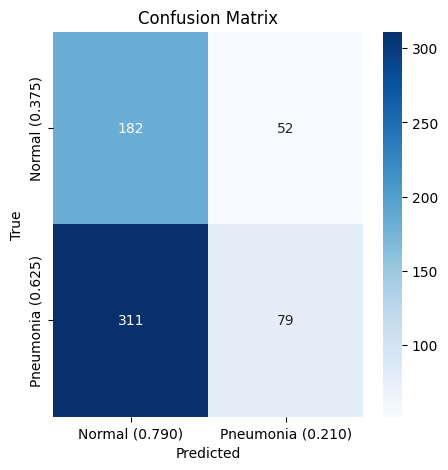

In [ ]:
model_1 = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer((150, 150, 1), name="input"),
    tf.keras.layers.Resizing(28, 28, name="resizing"), # mnist data set is 28 x 28 x 1
    transfer_model,
], name="Model_1")

metrics = [
    tf.keras.metrics.TruePositives(name='tp'),
    tf.keras.metrics.TrueNegatives(name='tn'),
    tf.keras.metrics.BinaryAccuracy(name='accuracy'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
]

model_1.compile(
    optimizer=tf.keras.optimizers.AdamW(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

y_pred = np.round(model_1.predict(test_ds))

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5, 5)
confusion_matrix_two_by_two(ax, y_true, y_pred)

In [16]:
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',
    save_best_only=True,
    monitor='val_loss',
    mode='min'
)

epochs = 10

history = model_1.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback]
)

Epoch 1/10


163/163 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.7876 - loss: 0.2320 - precision: 0.7882 - recall: 0.9799 - tn: 159.6402 - tp: 1926.2500 - val_accuracy: 0.5000 - val_loss: 1.4119 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 91ms/step - accuracy: 0.8249 - loss: 0.1825 - precision: 0.8224 - recall: 0.9785 - tn: 250.1646 - tp: 1923.3842 - val_accuracy: 0.5625 - val_loss: 1.4211 - val_precision: 0.5333 - val_recall: 1.0000 - val_tn: 1.0000 - val_tp: 8.0000
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.8344 - loss: 0.1680 - precision: 0.8315 - recall: 0.9779 - tn: 292.2561 - tp: 1922.5000 - val_accuracy: 0.6875 - val_loss: 0.5706 - val_precision: 0.6667 - val_recall: 0.7500 - val_tn: 5.0000 - val_tp: 6.0000
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.8406 - loss: 0.1620 - precision: 0.8379 - recall: 0.9762 - tn: 307.9207 - tp: 1919.2012 - val_accuracy: 0.75

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


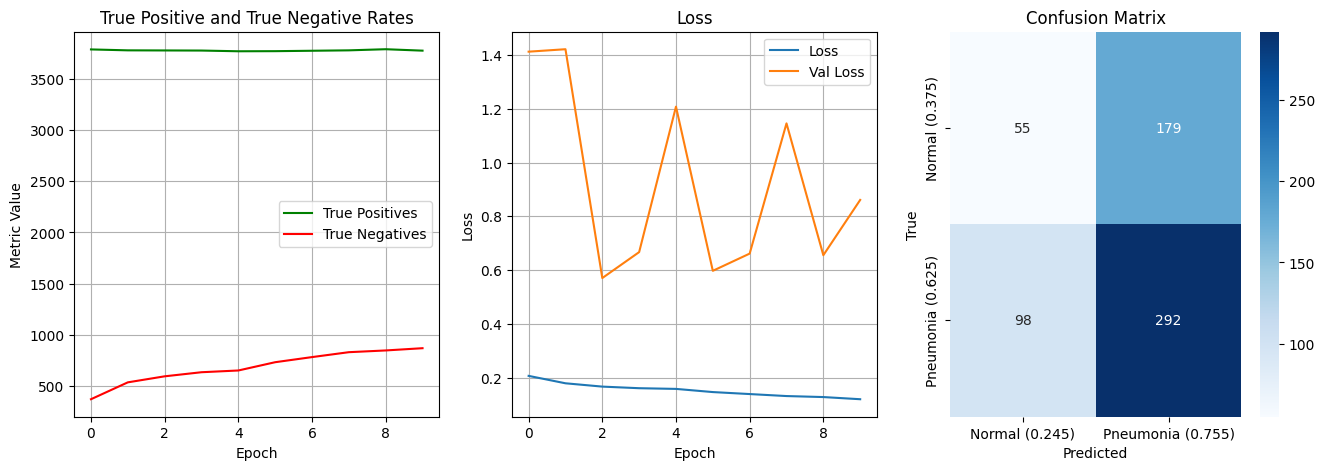

In [22]:
summary_graphics(history, model_1)

In [30]:
transfer_model = tf.keras.models.load_model('best_model_mnist.keras')
model_2 = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer((150, 150, 1), name="input"),
    tf.keras.layers.Resizing(28, 28, name="rescaling"),

    tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
    tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
    tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
    #tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),

    tf.keras.layers.Rescaling(1./255, name="rescale"),

    tf.keras.layers.Conv2D(16, (3,3), activation='relu', padding='same', name="1.1conv"),
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', padding='same', name="1.2conv"),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name="1.3pool"),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', name="2.1conv"),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', name="2.2conv"),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name="2.3pool"),

    tf.keras.layers.SeparableConv2D(64, (3,3), activation='relu', padding='same', name="3.1conv"),
    tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
    tf.keras.layers.SeparableConv2D(64, (3,3), activation='relu', padding='same', name="3.3conv"),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name='3.4pool'),

    tf.keras.layers.SeparableConv2D(64, (3,3), activation='relu', padding='same', name="4.1conv"),
    tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
    tf.keras.layers.SeparableConv2D(64, (3,3), activation='relu', padding='same', name='4.3conv'),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name="4.6pool"),

    tf.keras.layers.Flatten(name="5.1flatten"),

    tf.keras.layers.Dense(512, activation='relu', name="5.2dense"),
    tf.keras.layers.Dropout(0.5, name="5.3dropout"),
    tf.keras.layers.Dense(256, activation='relu', name="5.4dense"),
    tf.keras.layers.Dropout(0.4, name="5.5dropout"),

    tf.keras.layers.Dense(1, activation="sigmoid", name="output")
], name="Model_2")

# copy over the weights
model_2.get_layer("1.1conv").set_weights(transfer_model.get_layer("1.1conv").get_weights())
model_2.get_layer("1.2conv").set_weights(transfer_model.get_layer("1.2conv").get_weights())
model_2.get_layer("2.1conv").set_weights(transfer_model.get_layer("2.1conv").get_weights())
model_2.get_layer("2.2conv").set_weights(transfer_model.get_layer("2.2conv").get_weights())
model_2.get_layer("3.1conv").set_weights(transfer_model.get_layer("3.1conv").get_weights())
model_2.get_layer("3.3conv").set_weights(transfer_model.get_layer("3.3conv").get_weights())
model_2.get_layer("4.1conv").set_weights(transfer_model.get_layer("4.1conv").get_weights())
model_2.get_layer("4.3conv").set_weights(transfer_model.get_layer("4.3conv").get_weights())
model_2.get_layer("5.2dense").set_weights(transfer_model.get_layer("5.2dense").get_weights())
model_2.get_layer("5.4dense").set_weights(transfer_model.get_layer("5.4dense").get_weights())
#model_2.get_layer("output").set_weights(transfer_model.get_layer("output"))

model_2.compile(
    optimizer=tf.keras.optimizers.AdamW(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

In [31]:
history = model_2.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback]
)

Epoch 1/10


163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step - accuracy: 0.7330 - loss: 0.2799 - precision: 0.7491 - recall: 0.9647 - tn: 35.3598 - tp: 1942.7744 - val_accuracy: 0.5000 - val_loss: 0.7053 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.8026 - loss: 0.1888 - precision: 0.8035 - recall: 0.9761 - tn: 214.9207 - tp: 1920.7622 - val_accuracy: 0.6250 - val_loss: 0.6826 - val_precision: 0.5714 - val_recall: 1.0000 - val_tn: 2.0000 - val_tp: 8.0000
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.8215 - loss: 0.1785 - precision: 0.8234 - recall: 0.9713 - tn: 251.8049 - tp: 1917.8842 - val_accuracy: 0.7500 - val_loss: 0.6507 - val_precision: 0.8333 - val_recall: 0.6250 - val_tn: 7.0000 - val_tp: 5.0000
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.8506 - loss: 0.1567 - precision: 0.8472 - recall: 0.9768 - tn: 325.2256 - tp: 1917.0000 - val_accuracy: 0.8125

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


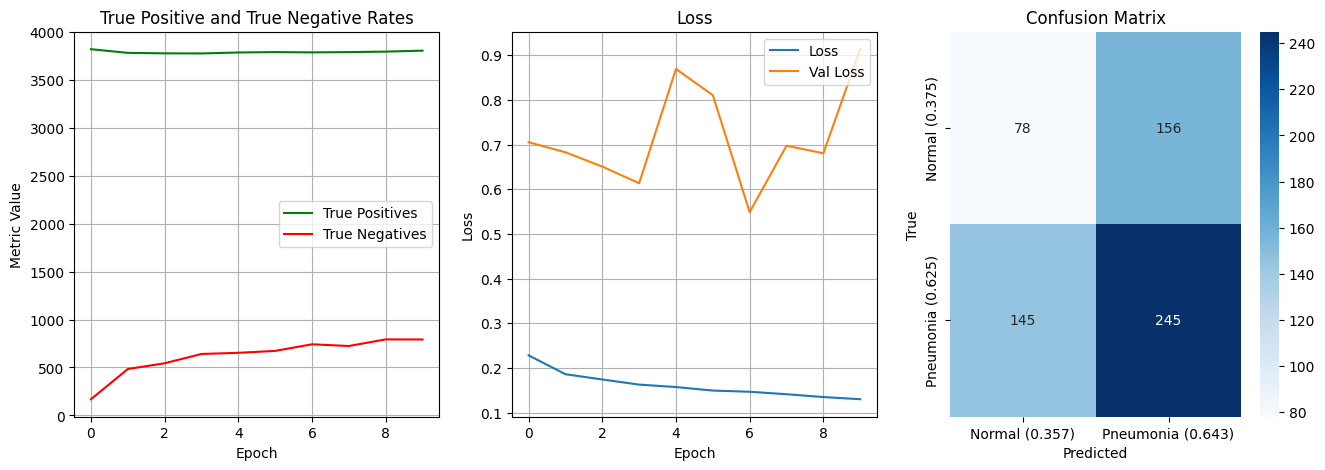

In [32]:
best_model = tf.keras.models.load_model('best_model.keras')
summary_graphics(history, best_model)

In [34]:
# continue doing transfer learning but increase dropout in the dense layers
transfer_model = tf.keras.models.load_model('best_model_mnist.keras')
model_3 = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer((150, 150, 1), name="input"),
    tf.keras.layers.Resizing(28, 28, name="rescaling"),

    tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
    tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
    tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
    #tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),

    tf.keras.layers.Rescaling(1./255, name="rescale"),

    tf.keras.layers.Conv2D(16, (3,3), activation='relu', padding='same', name="1.1conv"),
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', padding='same', name="1.2conv"),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name="1.3pool"),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', name="2.1conv"),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', name="2.2conv"),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name="2.3pool"),

    tf.keras.layers.SeparableConv2D(64, (3,3), activation='relu', padding='same', name="3.1conv"),
    tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
    tf.keras.layers.SeparableConv2D(64, (3,3), activation='relu', padding='same', name="3.3conv"),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name='3.4pool'),

    tf.keras.layers.SeparableConv2D(64, (3,3), activation='relu', padding='same', name="4.1conv"),
    tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
    tf.keras.layers.SeparableConv2D(64, (3,3), activation='relu', padding='same', name='4.3conv'),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name="4.6pool"),

    tf.keras.layers.Flatten(name="5.1flatten"),

    tf.keras.layers.Dense(512, activation='relu', name="5.2dense"),
    tf.keras.layers.Dropout(0.7, name="5.3dropout"),
    tf.keras.layers.Dense(256, activation='relu', name="5.4dense"),
    tf.keras.layers.Dropout(0.5, name="5.5dropout"),

    tf.keras.layers.Dense(1, activation="sigmoid", name="output")
], name="Model_3")

# copy over the weights
layer_names = ["1.1conv", "1.2conv", "2.1conv", "2.2conv", "3.1conv", "3.3conv", "4.1conv", "4.3conv", "5.2dense", "5.4dense"]

for layer_name in layer_names:
    model_3.get_layer(layer_name).set_weights(transfer_model.get_layer(layer_name).get_weights())

model_3.compile(
    optimizer=tf.keras.optimizers.AdamW(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

In [35]:
history = model_3.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.7431 - loss: 0.2567 - precision: 0.7566 - recall: 0.9694 - tn: 57.3171 - tp: 1942.2988 - val_accuracy: 0.5000 - val_loss: 0.7071 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.8190 - loss: 0.1791 - precision: 0.8192 - recall: 0.9744 - tn: 239.0854 - tp: 1917.7317 - val_accuracy: 0.5000 - val_loss: 0.7022 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.8211 - loss: 0.1745 - precision: 0.8223 - recall: 0.9720 - tn: 263.7195 - tp: 1914.4634 - val_accuracy: 0.6250 - val_loss: 0.6536 - val_precision: 0.5714 - val_recall: 1.0000 - val_tn: 2.0000 - val_tp: 8.0000
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.8302 - loss: 0.1652 - precision: 0.8280 - recall: 0.9752 - tn: 282.3354 - tp: 1916.1097 - val_acc

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


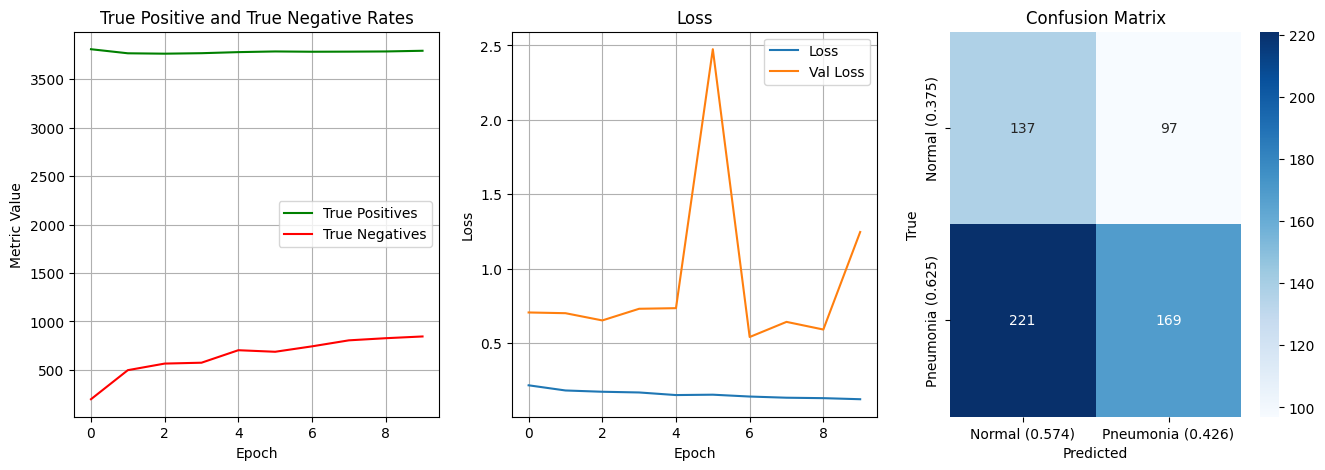

In [36]:
best_model = tf.keras.models.load_model('best_model.keras')
summary_graphics(history, best_model)

In [37]:
# add in a small amount of dropout everywhere
transfer_model = tf.keras.models.load_model('best_model_mnist.keras')
model_4 = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer((150, 150, 1), name="input"),
    tf.keras.layers.Resizing(28, 28, name="rescaling"),

    tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
    tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
    tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
    #tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),

    tf.keras.layers.Rescaling(1./255, name="rescale"),

    tf.keras.layers.Conv2D(16, (3,3), activation='relu', padding='same', name="1.1conv"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', padding='same', name="1.2conv"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name="1.3pool"),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', name="2.1conv"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', name="2.2conv"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name="2.3pool"),

    tf.keras.layers.SeparableConv2D(64, (3,3), activation='relu', padding='same', name="3.1conv"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
    tf.keras.layers.SeparableConv2D(64, (3,3), activation='relu', padding='same', name="3.3conv"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name='3.4pool'),

    tf.keras.layers.SeparableConv2D(64, (3,3), activation='relu', padding='same', name="4.1conv"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
    tf.keras.layers.SeparableConv2D(64, (3,3), activation='relu', padding='same', name='4.3conv'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name="4.6pool"),

    tf.keras.layers.Flatten(name="5.1flatten"),

    tf.keras.layers.Dense(512, activation='relu', name="5.2dense"),
    tf.keras.layers.Dropout(0.5, name="5.3dropout"),
    tf.keras.layers.Dense(256, activation='relu', name="5.4dense"),
    tf.keras.layers.Dropout(0.4, name="5.5dropout"),

    tf.keras.layers.Dense(1, activation="sigmoid", name="output")
], name="Model_4")

# copy over the weights
layer_names = ["1.1conv", "1.2conv", "2.1conv", "2.2conv", "3.1conv", "3.3conv", "4.1conv", "4.3conv", "5.2dense", "5.4dense"]

for layer_name in layer_names:
    model_4.get_layer(layer_name).set_weights(transfer_model.get_layer(layer_name).get_weights())

model_4.compile(
    optimizer=tf.keras.optimizers.AdamW(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.7563 - loss: 0.2495 - precision: 0.7613 - recall: 0.9819 - tn: 75.8476 - tp: 1947.6403 - val_accuracy: 0.5000 - val_loss: 0.6924 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_tn: 8.0000 - val_tp: 0.0000e+00
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.8115 - loss: 0.1862 - precision: 0.8132 - recall: 0.9727 - tn: 218.7927 - tp: 1914.6830 - val_accuracy: 0.5000 - val_loss: 0.6896 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.8181 - loss: 0.1824 - precision: 0.8147 - recall: 0.9812 - tn: 217.7195 - tp: 1929.7134 - val_accuracy: 0.5000 - val_loss: 0.6553 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.8127 - loss: 0.1790 - precision: 0.8108 - recall: 0.9797 - tn: 215.5610 - tp: 1925

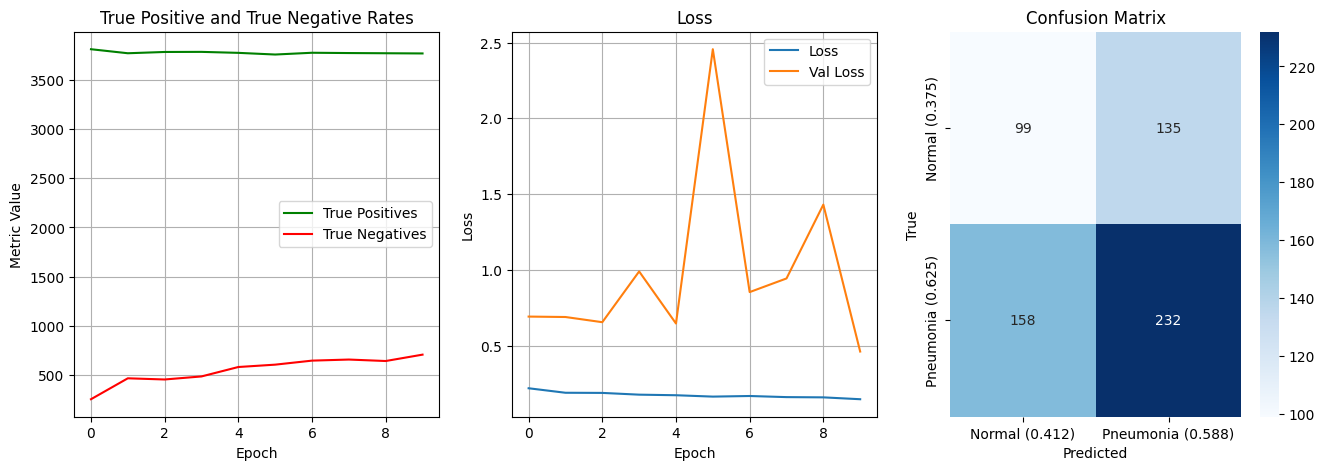

In [38]:
history = model_4.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback]
)
best_model = tf.keras.models.load_model('best_model.keras')
summary_graphics(history, best_model)

In [39]:
# go back to original model, copy only early layers, and freeze them
transfer_model = tf.keras.models.load_model('best_model_mnist.keras')
model_5 = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer((150, 150, 1), name="input"),
    tf.keras.layers.Resizing(28, 28, name="rescaling"),

    tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
    tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
    tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
    #tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),

    tf.keras.layers.Rescaling(1./255, name="rescale"),

    tf.keras.layers.Conv2D(16, (3,3), activation='relu', padding='same', name="1.1conv"),
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', padding='same', name="1.2conv"),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name="1.3pool"),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', name="2.1conv"),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', name="2.2conv"),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name="2.3pool"),

    tf.keras.layers.SeparableConv2D(64, (3,3), activation='relu', padding='same', name="3.1conv"),
    tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
    tf.keras.layers.SeparableConv2D(64, (3,3), activation='relu', padding='same', name="3.3conv"),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name='3.4pool'),

    tf.keras.layers.SeparableConv2D(64, (3,3), activation='relu', padding='same', name="4.1conv"),
    tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
    tf.keras.layers.SeparableConv2D(64, (3,3), activation='relu', padding='same', name='4.3conv'),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name="4.6pool"),

    tf.keras.layers.Flatten(name="5.1flatten"),

    tf.keras.layers.Dense(512, activation='relu', name="5.2dense"),
    tf.keras.layers.Dropout(0.5, name="5.3dropout"),
    tf.keras.layers.Dense(256, activation='relu', name="5.4dense"),
    tf.keras.layers.Dropout(0.4, name="5.5dropout"),

    tf.keras.layers.Dense(1, activation="sigmoid", name="output")
], name="Model_5")

# copy over the weights
layer_names = ["1.1conv", "1.2conv", "2.1conv", "2.2conv",]# "3.1conv", "3.3conv", "4.1conv", "4.3conv", "5.2dense", "5.4dense"]

for layer_name in layer_names:
    model_5.get_layer(layer_name).set_weights(transfer_model.get_layer(layer_name).get_weights())
    model_5.get_layer(layer_name).trainable = False

model_5.compile(
    optimizer=tf.keras.optimizers.AdamW(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.7490 - loss: 0.2713 - precision: 0.7595 - recall: 0.9724 - tn: 69.0122 - tp: 1949.0244 - val_accuracy: 0.5000 - val_loss: 0.6974 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.8209 - loss: 0.1773 - precision: 0.8199 - recall: 0.9752 - tn: 252.6037 - tp: 1919.7988 - val_accuracy: 0.5000 - val_loss: 0.6906 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_tn: 8.0000 - val_tp: 0.0000e+00
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.8495 - loss: 0.1591 - precision: 0.8475 - recall: 0.9750 - tn: 317.7256 - tp: 1916.7195 - val_accuracy: 0.6250 - val_loss: 0.6578 - val_precision: 1.0000 - val_recall: 0.2500 - val_tn: 8.0000 - val_tp: 2.0000
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.8498 - loss: 0.1607 - precision: 0.8467 - recall: 0.9763 - tn: 319.0610 - tp: 1918.8842 - 

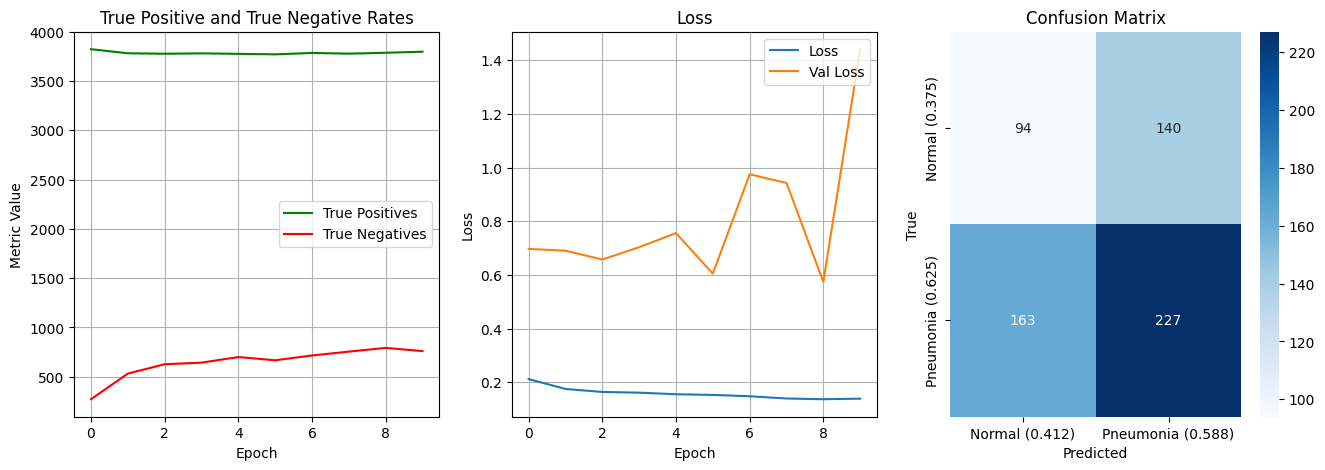

In [40]:
history = model_5.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback]
)
best_model = tf.keras.models.load_model('best_model.keras')
summary_graphics(history, best_model)

In [41]:
# do something similar to model 5 but increase number of neurons in later layers
transfer_model = tf.keras.models.load_model('best_model_mnist.keras')
model_6 = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer((150, 150, 1), name="input"),
    tf.keras.layers.Resizing(28, 28, name="rescaling"),

    tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
    tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
    tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
    #tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),

    tf.keras.layers.Rescaling(1./255, name="rescale"),

    tf.keras.layers.Conv2D(16, (3,3), activation='relu', padding='same', name="1.1conv"),
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', padding='same', name="1.2conv"),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name="1.3pool"),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', name="2.1conv"),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', name="2.2conv"),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name="2.3pool"),

    tf.keras.layers.SeparableConv2D(64, (3,3), activation='relu', padding='same', name="3.1conv"),
    tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
    tf.keras.layers.SeparableConv2D(64, (3,3), activation='relu', padding='same', name="3.3conv"),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name='3.4pool'),

    tf.keras.layers.SeparableConv2D(128, (3,3), activation='relu', padding='same', name="4.1conv"),
    tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
    tf.keras.layers.SeparableConv2D(128, (3,3), activation='relu', padding='same', name='4.3conv'),
    tf.keras.layers.MaxPooling2D((2,2), padding='same', name="4.6pool"),

    tf.keras.layers.Flatten(name="5.1flatten"),

    tf.keras.layers.Dense(1024, activation='relu', name="5.2dense"),
    tf.keras.layers.Dropout(0.5, name="5.3dropout"),
    tf.keras.layers.Dense(512, activation='relu', name="5.4dense"),
    tf.keras.layers.Dropout(0.4, name="5.5dropout"),

    tf.keras.layers.Dense(1, activation="sigmoid", name="output")
], name="Model_6")

# copy over the weights
layer_names = ["1.1conv", "1.2conv", "2.1conv", "2.2conv",]# "3.1conv", "3.3conv", "4.1conv", "4.3conv", "5.2dense", "5.4dense"]

for layer_name in layer_names:
    model_6.get_layer(layer_name).set_weights(transfer_model.get_layer(layer_name).get_weights())
    model_6.get_layer(layer_name).trainable = False

model_6.compile(
    optimizer=tf.keras.optimizers.AdamW(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.7406 - loss: 0.2790 - precision: 0.7473 - recall: 0.9852 - tn: 10.2073 - tp: 1962.6647 - val_accuracy: 0.5000 - val_loss: 0.7034 - val_precision: 0.5000 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 8.0000
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.8153 - loss: 0.1748 - precision: 0.8117 - recall: 0.9813 - tn: 231.3415 - tp: 1927.0853 - val_accuracy: 0.5000 - val_loss: 0.7126 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_tn: 8.0000 - val_tp: 0.0000e+00
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.8263 - loss: 0.1689 - precision: 0.8270 - recall: 0.9732 - tn: 268.6158 - tp: 1920.4817 - val_accuracy: 0.5000 - val_loss: 0.7231 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_tn: 8.0000 - val_tp: 0.0000e+00
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.8473 - loss: 0.1559 - precision: 0.8445 - recall: 0.9758 - tn: 318.1890 - tp: 

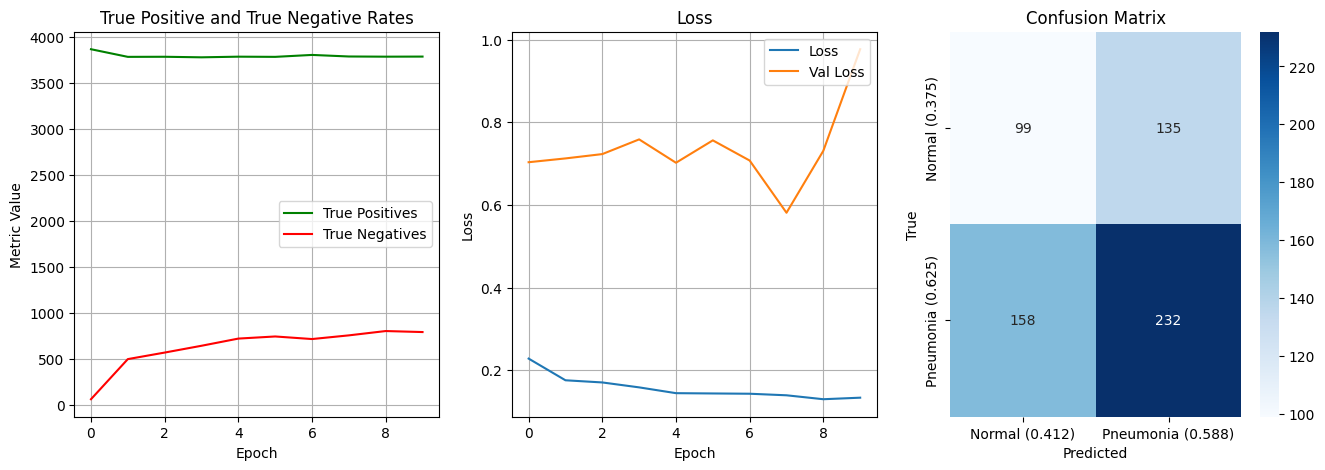

In [ ]:
history = model_6.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=[checkpoint_callback]
)
best_model = tf.keras.models.load_model('best_model.keras')
summary_graphics(history, best_model)

In [8]:
notebook_end_time = datetime.datetime.now()
print(f"Notebook last run (end-to-end): {notebook_end_time} (duration: {notebook_end_time - notebook_start_time})")

Notebook last run (end-to-end): 2025-05-09 22:48:50.822631 (duration: 0:02:29.646288)
